In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Simple Linear Regression

In [3]:
codecademy = pd.read_csv('codecademy.csv')

In [4]:
# Print the first five rows
codecademy.head()

,score,completed,lesson
0,82.7,35.0,Lesson A
1,65.2,31.0,Lesson A
2,55.3,33.0,Lesson A
3,28.8,25.0,Lesson B
4,31.2,18.0,Lesson B


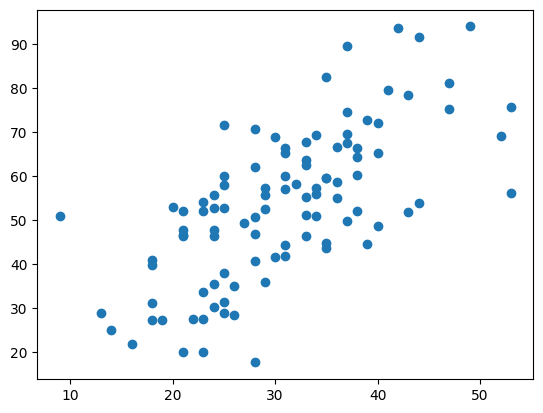

In [5]:
# Create a scatter plot of score vs completed
plt.scatter(codecademy.completed, codecademy.score)

In [6]:
# Fit a linear regression to predict score based on prior lessons completed
model = sm.OLS.from_formula('score ~ completed', data=codecademy)
res = model.fit()
res.params

Intercept    13.214113
completed     1.306826
dtype: float64

Intercept interpretation:

the expected value of the outcome variable when the predictor variable is equal to zero.

Slope interpretation:

expected difference in the outcome variable for a one unit increase in the predictor variable.

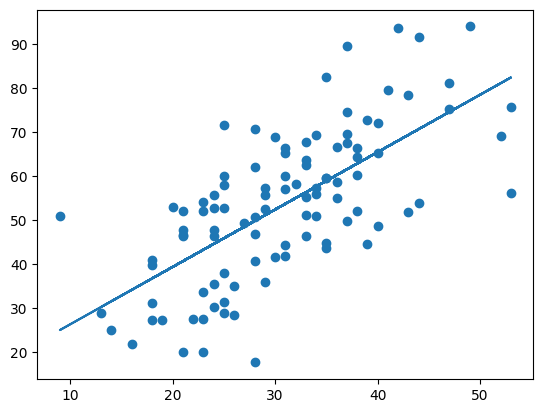

In [7]:
# Plot the scatter plot with the line on top
plt.scatter(codecademy.completed, codecademy.score)
plt.plot(codecademy.completed, res.predict(codecademy.completed))

In [8]:
# Predict score for learner who has completed 20 prior lessons
newdata = {'completed':[20]}
res.predict(newdata)

0    39.350625
dtype: float64

In [9]:
# Calculate fitted values
fitted_values = res.predict(codecademy)

In [10]:
# Calculate residuals
residuals = codecademy.score - fitted_values

(array([ 2.,  2., 13., 14.,  9., 19., 19., 13.,  4.,  5.]),
 array([-32.20522962, -26.17137265, -20.13751569, -14.10365872,
         -8.06980175,  -2.03594479,   3.99791218,  10.03176915,
         16.06562611,  22.09948308,  28.13334004]),
 <BarContainer object of 10 artists>)

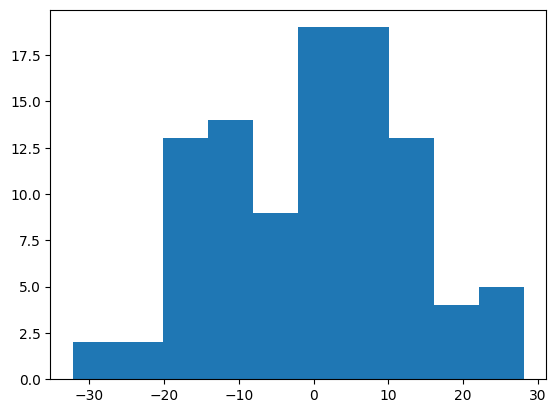

In [11]:
# Check normality assumption
plt.hist(residuals)

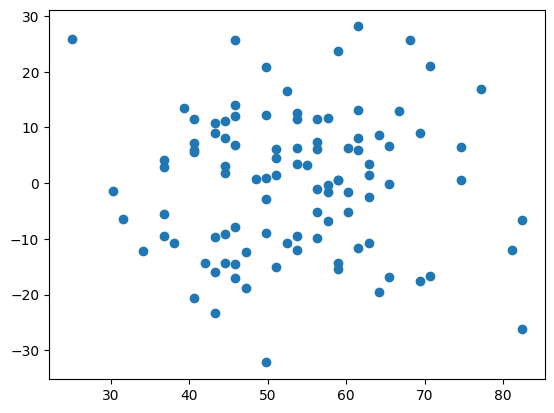

In [12]:
# Check homoscedasticity assumption
plt.scatter(fitted_values, residuals)

<Axes: xlabel='lesson', ylabel='score'>

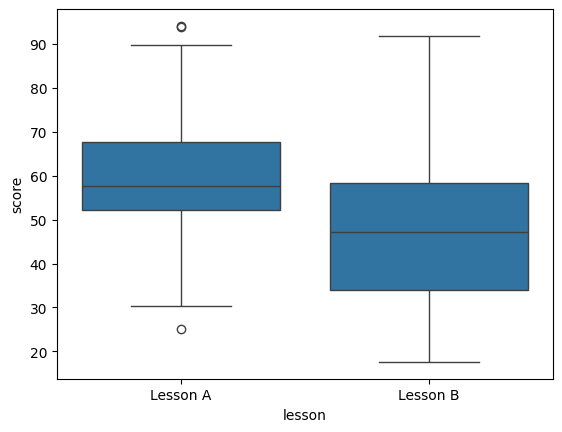

In [13]:
# Create a boxplot of score vs lesson
sns.boxplot(x='lesson', y='score', data=codecademy)

In [14]:
# Fit a linear regression to predict score based on which lesson they took
model = sm.OLS.from_formula('score ~ lesson', data=codecademy)
res = model.fit()
res.params

Intercept             59.220
lesson[T.Lesson B]   -11.642
dtype: float64

In [15]:
# Calculate and print the group means and mean difference (for comparison)
print(np.mean(codecademy.score[codecademy.lesson == 'Lesson A']))
print(np.mean(codecademy.score[codecademy.lesson == 'Lesson B']))

59.220000000000006
47.578


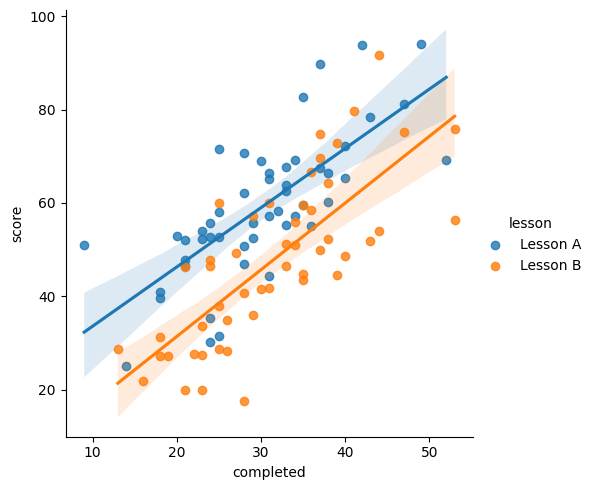

In [16]:
# Use `sns.lmplot()` to plot `score` vs. `completed` colored by `lesson`
sns.lmplot(x='completed', y='score', hue='lesson', data=codecademy)

In [17]:
forests = pd.read_csv('forests.csv')

In [ ]:
# check multicollinearity with a heatmap
corr_grid = forests.corr()

In [ ]:
sns.heatmap(corr_grid, xticklabels=corr_grid.columns, yticklabels=corr_grid.columns, annot=True)

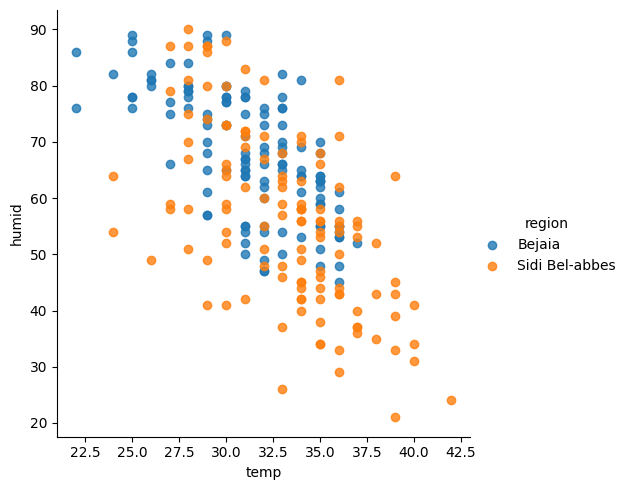

In [21]:
# plot humidity vs temperature
sns.lmplot(x='temp',y='humid',hue='region',data=forests, fit_reg = False)

In [22]:
# model predicting humidity
modelH = sm.OLS.from_formula('humid ~ temp + region',data=forests).fit()
modelH.params

Intercept                   142.575801
region[T.Sidi Bel-abbes]     -7.247538
temp                         -2.392547
dtype: float64

In [ ]:
#equations
## Full equation:
# humid = 142.6 - 2.4*temp - 7.2*region
## For Bejaia:
# humid = 142.6 - 2.4*temp
## For Sidi Bel-abbes:
# humid = 135.3 - 2.4*temp

#interpretations
## Coefficient on temp:
# Holding region constant, the coefficient on temperature indicates that for every temperature increase of one-degree Celsius, relative humidity decreases by 2.4%. 
## For Bejaia equation:
# The intercept indicates that a temperature of zero degrees Celsius is associated with an average relative humidity of 142.6%. (This interpretation is doesn't make sense as relative humidity can't go past 100% and 0 degrees C is far below the temperatures available in our dataset, but we learn the regression line starts higher for Bejaia.)
## For Sidi Bel-abbes equation:
# The intercept indicates that a temperature of zero degrees Celsius is associated with an average relative humidity of 135.3%. (This interpretation is doesn't make sense as relative humidity can't go past 100% and 0 degrees C is far below the temperatures available in our dataset, but we learn the regression line starts lower for Sidi Bel-abbes.)

/tmp/ipykernel_606808/1497810211.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(forests.temp, modelH.params[0]+modelH.params[1]*0+modelH.params[2]*forests.temp, color='blue',linewidth=5, label='Bejaia')
/tmp/ipykernel_606808/1497810211.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(forests.temp, modelH.params[0]+modelH.params[1]*1+modelH.params[2]*forests.temp, color='orange',linewidth=5, label='Sidi Bel-abbes')


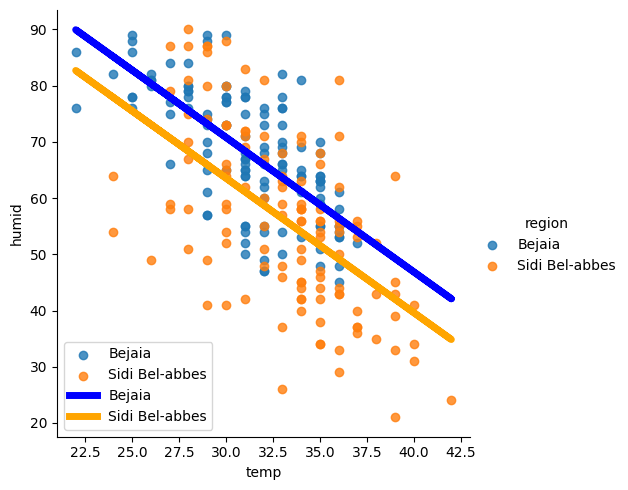

In [23]:
# plot regression lines
sns.lmplot(x='temp',y='humid',hue='region',data=forests, fit_reg = False)
plt.plot(forests.temp, modelH.params[0]+modelH.params[1]*0+modelH.params[2]*forests.temp, color='blue',linewidth=5, label='Bejaia')
plt.plot(forests.temp, modelH.params[0]+modelH.params[1]*1+modelH.params[2]*forests.temp, color='orange',linewidth=5, label='Sidi Bel-abbes')
plt.legend()

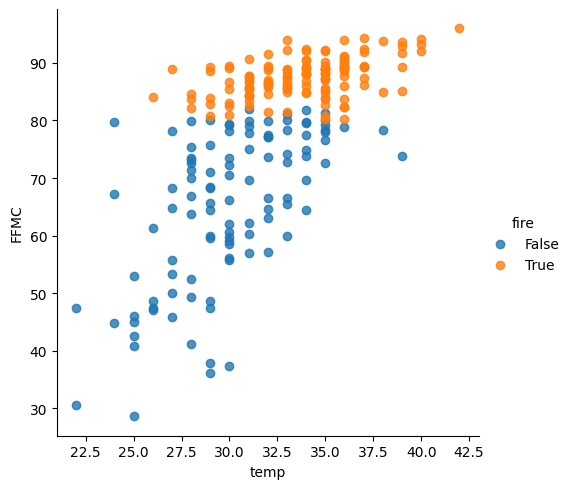

In [24]:
# plot FFMC vs temperature
sns.lmplot(x='temp',y='FFMC',hue='fire',data=forests, fit_reg = False)

In [25]:
# model predicting FFMC with interaction
modelF = sm.OLS.from_formula('FFMC ~ temp + fire + temp:fire',data=forests).fit()
modelF.params

Intercept            -8.108891
fire[T.True]         76.788000
temp                  2.445159
temp:fire[T.True]    -1.887219
dtype: float64

In [ ]:
#equations
## Full equation:
# FFMC = -8.1 + 2.4*temp + 76.8*fire - 1.9*temp*fire
## For locations without fire:
# FFMC = -8.1 + 2.4*temp
## For locations with fire:
# FFMC = 68.7 + 0.5*temp

#interpretations
## For locations without fire:
# FFMC = -8.1 + 2.4*temp
# For every temperature increase of one degree Celsius, FFMC score increases by 2.4 points.
## For locations with fire:
# FFMC = 68.7 + 0.5*temp
# The regression line has an intercept 76.8 points greater and a slope 1.9 points less than those of the locations that did not end up experiencing a fire. 
# For every temperature increase of one degree Celsius, FFMC score increases by 0.5 points.

/tmp/ipykernel_606808/2711860962.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(forests.temp, modelF.params[0]+modelF.params[1]*0+modelF.params[2]*forests.temp + modelF.params[3]*forests.temp*0, color='blue',linewidth=5, label='No Fire')
/tmp/ipykernel_606808/2711860962.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(forests.temp, modelF.params[0]+modelF.params[1]*1+modelF.params[2]*forests.temp + modelF.params[3]*forests.temp*1, color='orange',linewidth=5, label='Fire')


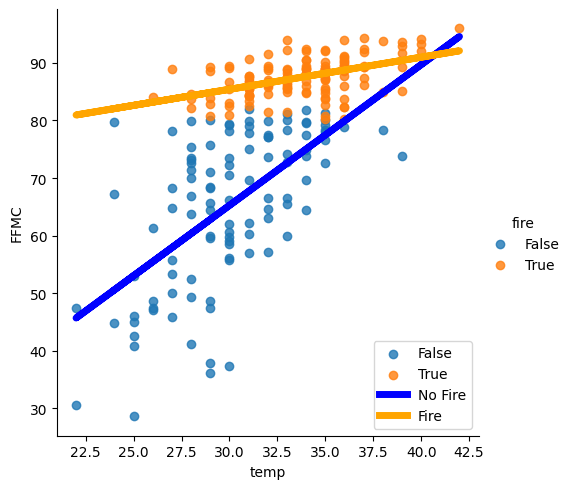

In [26]:
# plot regression lines
sns.lmplot(x='temp',y='FFMC',hue='fire',data=forests, fit_reg = False)
plt.plot(forests.temp, modelF.params[0]+modelF.params[1]*0+modelF.params[2]*forests.temp + modelF.params[3]*forests.temp*0, color='blue',linewidth=5, label='No Fire')
plt.plot(forests.temp, modelF.params[0]+modelF.params[1]*1+modelF.params[2]*forests.temp + modelF.params[3]*forests.temp*1, color='orange',linewidth=5, label='Fire')
plt.legend()

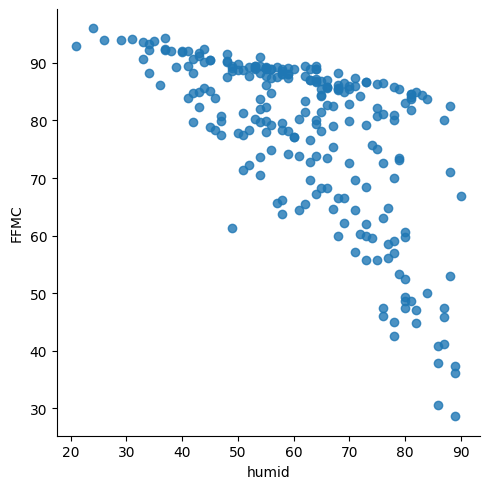

In [27]:
# plot FFMC vs humid
sns.lmplot(x='humid',y='FFMC',data=forests, fit_reg = False)

In [28]:
# polynomial model predicting FFMC
modelP = sm.OLS.from_formula('FFMC ~ humid + np.power(humid,2)',data=forests).fit()
modelP.params

Intercept             77.634041
humid                  0.752165
np.power(humid, 2)    -0.011420
dtype: float64

In [ ]:
#regression equation
# FFMC = 77.63 + 0.75*humid - 0.01*humid^2

In [29]:
# sample predicted values
print(modelP.params[0] + modelP.params[1]*25 + modelP.params[2]*np.power(25,2))
print(modelP.params[0] + modelP.params[1]*35 + modelP.params[2]*np.power(35,2))
print(modelP.params[0] + modelP.params[1]*60 + modelP.params[2]*np.power(60,2))
print(modelP.params[0] + modelP.params[1]*70 + modelP.params[2]*np.power(70,2))

89.30075097131991
89.97048469230963
81.65244328464414
74.32827643752202


/tmp/ipykernel_606808/542104164.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(modelP.params[0] + modelP.params[1]*25 + modelP.params[2]*np.power(25,2))
/tmp/ipykernel_606808/542104164.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(modelP.params[0] + modelP.params[1]*35 + modelP.params[2]*np.power(35,2))
/tmp/ipykernel_606808/542104164.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(modelP.params[0] +

In [ ]:
#interpretation of relationship
# For lower humidity levels, increases in relative humidity are associated with very small increases in FFMC score, until about 35% relative humidity. After this point increases in humidity are associated with increasingly bigger decreases in FFMC score.

In [30]:
# multiple variables to predict FFMC
modelFFMC = sm.OLS.from_formula('FFMC ~ temp + rain + wind + humid',data=forests).fit()
modelFFMC.params

Intercept    50.461574
temp          1.377774
rain         -2.614067
wind          0.419784
humid        -0.345373
dtype: float64

In [31]:
# predict FWI from ISI and BUI
modelFWI = sm.OLS.from_formula('FWI ~ ISI + BUI',data=forests).fit()
modelFWI.params

Intercept   -2.270676
ISI          1.133400
BUI          0.235526
dtype: float64

In [32]:
np.random.seed(10)

# Import data
housing = pd.read_csv('craiglist-housing.csv')

In [33]:
# Fit model1
model1 = sm.OLS.from_formula('price ~ type + sqfeet + beds + baths', data=housing).fit()

# Fit model2
model2 = sm.OLS.from_formula('price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed', data=housing).fit()

# Fit model3
model3 = sm.OLS.from_formula('price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed', data=housing).fit()

# Print R-squared for all models
print(model1.rsquared)
print(model2.rsquared)
print(model3.rsquared)

0.12781764439123167
0.2819152527603437
0.2838226722379378


In [34]:
# Print adjusted R-squared for all models
print(model1.rsquared_adj)
print(model2.rsquared_adj)
print(model3.rsquared_adj)

0.12571895013269851
0.2762905680561166
0.27774148003616983


In [35]:
# Run an F test comparing model2 and model3
from statsmodels.stats.anova import anova_lm
anova_results = anova_lm(model2, model3)
anova_results.round(2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,3064.0,5.270049e+08,0.0,NaN,NaN,NaN
1,3062.0,5.256050e+08,2.0,1399861.77,4.08,0.02


In [36]:
# Print log likelihood for all models
print(model1.llf)
print(model2.llf)
print(model3.llf)

-37528.12294065279
-22989.87439522474
-22985.76634388421


In [37]:
# Print AIC for all models
print(model1.aic)
print(model2.aic)
print(model3.aic)

75082.24588130559
46029.74879044948
46025.53268776842


In [38]:
# Print BIC for all models
print(model1.bic)
print(model2.bic)
print(model3.bic)

75166.969392794
46180.63885777244
46188.49396047722


In [39]:
# Split housing data
indices = range(len(housing))
s = int(0.8*len(indices))
train_ind = np.random.choice(indices, size = s, replace = False)
test_ind = list(set(indices) - set(train_ind))
housing_train = housing.iloc[train_ind]
housing_test = housing.iloc[test_ind]

In [40]:
# Fit model2 with training data
model2_train = sm.OLS.from_formula('price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed', data=housing_train).fit()

# Fit model3 with training data
model3_train = sm.OLS.from_formula('price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed', data=housing_train).fit()

# Calculate predicted price based on model2
fitted_mod2 = model2_train.predict(housing_test)

# Calculate predicted price based on model3
fitted_mod3 = model3_train.predict(housing_test)

# Calculate PRMSE for model2
prmse2 = np.mean((housing_test.price - fitted_mod2)**2)**.5

# Calculate PRMSE for model3
prmse3 = np.mean((housing_test.price - fitted_mod3)**2)**.5

# Print PRMSE for both models
print(prmse2)
print(prmse3)

402.8697625214145
403.87729905190014


In [41]:
from sklearn.datasets import load_diabetes

In [42]:
# Import the data set
X, y = load_diabetes(return_X_y=True)

# Create the OLS linear regression model
ols = LinearRegression()

# Fit the model to the data
ols.fit(X, y)

# Print the coefficients of the model
print(ols.coef_)

# Print R^2
print(ols.score(X, y))

[ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]
0.5177484222203499


In [43]:
from sklearn.linear_model import SGDRegressor

In [44]:
# Import the data set
X, y = load_diabetes(return_X_y=True)

# Create the SGD linear regression model
# max_iter is the maximum number of iterations of SGD to try before halting
sgd = SGDRegressor(max_iter = 10000)

# Fit the model to the data
sgd.fit(X, y)

# Print the coefficients of the model
print(sgd.coef_)

# Print R^2
print(sgd.score(X, y))

[  13.67505267 -173.26988355  458.75400806  288.36505971  -31.34934435
  -92.00514155 -202.28562045  130.54145263  382.50223498  125.16077541]
0.5069627298150026


In [8]:
df = pd.read_csv('tennis_stats.csv')

In [4]:
df.head()

,Player,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
0,Pedro Sousa,2016,0.88,0.50,0.38,0.50,0.39,0,0.14,7,...,0.11,0.38,8,0.50,0.43,0.50,1,2,39820,119
1,Roman Safiullin,2017,0.84,0.62,0.26,0.33,0.07,7,0.00,7,...,0.00,0.20,9,0.67,0.41,0.57,0,1,17334,381
2,Pedro Sousa,2017,0.83,0.60,0.28,0.53,0.44,2,0.38,10,...,0.16,0.34,17,0.65,0.45,0.59,4,1,109827,119
3,Rogerio Dutra Silva,2010,0.83,0.64,0.34,0.59,0.33,2,0.33,5,...,0.14,0.34,15,0.80,0.49,0.63,0,0,9761,125
4,Daniel Gimeno-Traver,2017,0.81,0.54,0.00,0.33,0.33,1,0.00,2,...,0.00,0.20,2,0.50,0.35,0.50,0,1,32879,272


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1721 entries, 0 to 1720
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Player                      1721 non-null   object 
 1   Year                        1721 non-null   int64  
 2   FirstServe                  1721 non-null   float64
 3   FirstServePointsWon         1721 non-null   float64
 4   FirstServeReturnPointsWon   1721 non-null   float64
 5   SecondServePointsWon        1721 non-null   float64
 6   SecondServeReturnPointsWon  1721 non-null   float64
 7   Aces                        1721 non-null   int64  
 8   BreakPointsConverted        1721 non-null   float64
 9   BreakPointsFaced            1721 non-null   int64  
 10  BreakPointsOpportunities    1721 non-null   int64  
 11  BreakPointsSaved            1721 non-null   float64
 12  DoubleFaults                1721 non-null   int64  
 13  ReturnGamesPlayed           1721 

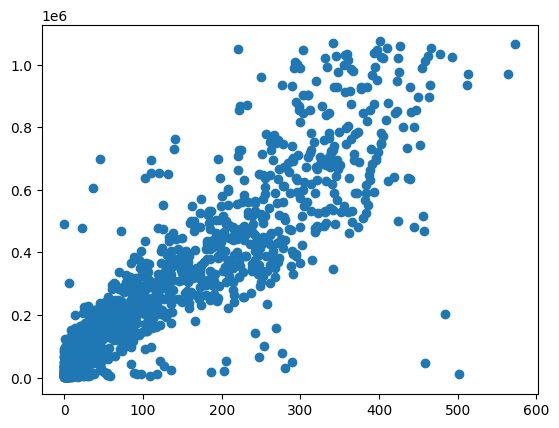

In [9]:
# perform exploratory analysis here:
plt.scatter(df.BreakPointsOpportunities, df.Winnings)

In [ ]:
## perform single feature linear regressions here:
X = df[['BreakPointsOpportunities']]

In [12]:
y = df[['Winnings']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7930077383154636

In [14]:
pred = model.predict(X_test)

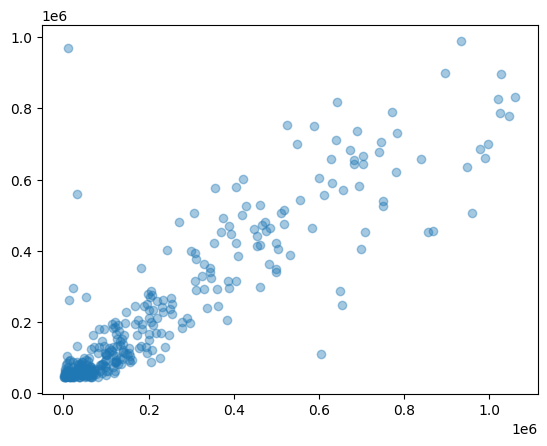

In [15]:
plt.scatter(y_test, pred, alpha=0.4)

In [16]:
## perform two feature linear regressions here:
X = df[['BreakPointsOpportunities', 'FirstServeReturnPointsWon']]

In [ ]:
y = df[['Winnings']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

In [ ]:
pred = model.predict(X_test)

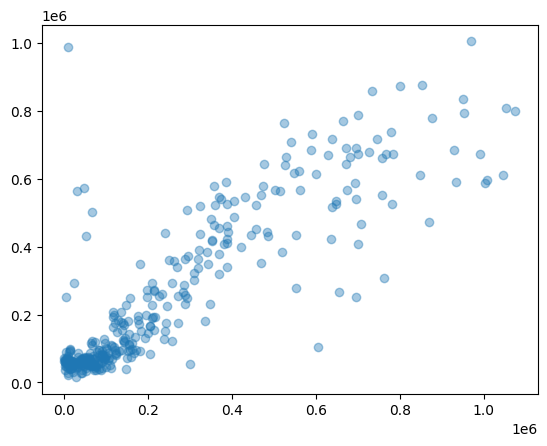

In [21]:
plt.scatter(y_test, pred, alpha=0.4)

In [22]:
## perform multiple feature linear regressions here:
X = df[['FirstServe','FirstServePointsWon','FirstServeReturnPointsWon',
    'SecondServePointsWon','SecondServeReturnPointsWon','Aces',
    'BreakPointsConverted','BreakPointsFaced','BreakPointsOpportunities',
    'BreakPointsSaved','DoubleFaults','ReturnGamesPlayed','ReturnGamesWon',
    'ReturnPointsWon','ServiceGamesPlayed','ServiceGamesWon','TotalPointsWon',
    'TotalServicePointsWon']]

In [23]:
y = df[['Winnings']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8593987234582801

In [25]:
pred = model.predict(X_test)

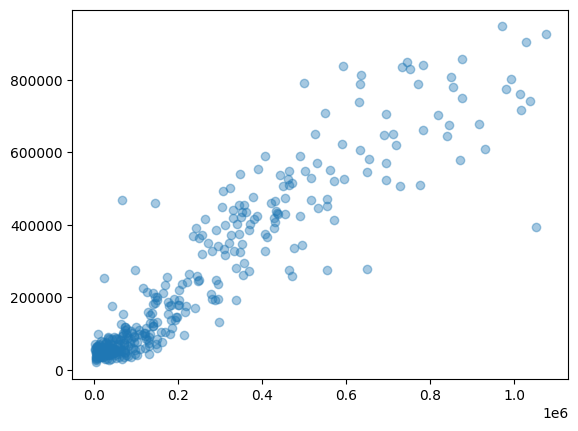

In [26]:
plt.scatter(y_test, pred, alpha=0.4)